In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [10]:
# Load all datasets
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

In [11]:
# Overview of all datasets
datasets = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{'='*40}")
    print(f"Table: {name}")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)}")
    print()

Table: orders
Shape: 99441 rows x 8 columns
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Table: order_items
Shape: 112650 rows x 7 columns
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Table: customers
Shape: 99441 rows x 5 columns
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Table: sellers
Shape: 3095 rows x 4 columns
Columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Table: products
Shape: 32951 rows x 9 columns
Columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Table: payments
Shape: 103886 rows x 5 columns
Column

In [12]:
# Check missing values in each table
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]  # only show columns that have missing values
    
    print(f"{'='*40}")
    print(f"Table: {name}")
    if len(missing) == 0:
        print("No missing values! ✅")
    else:
        print(missing)
    print()

Table: orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Table: order_items
No missing values! ✅

Table: customers
No missing values! ✅

Table: sellers
No missing values! ✅

Table: products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Table: payments
No missing values! ✅

Table: reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

Table: geolocation
No missing values! ✅

Table: category_translation
No missing values! ✅



In [13]:
# Handle missing values

# 1. Products - fill missing category with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# 2. Products - fill missing numeric columns with median
numeric_cols = ['product_name_lenght', 'product_description_lenght', 
                'product_photos_qty', 'product_weight_g',
                'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in numeric_cols:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)

# 3. Verify fixes
print("Missing values in products after fix:")
print(products.isnull().sum())

Missing values in products after fix:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [14]:
# Translate Portuguese category names to English

# Merge products with translation table
products = products.merge(
    category_translation,       # the translation lookup table
    on='product_category_name',  # match on this column
    how='left'                   # keep all products even if no translation exists
)

# For 'unknown' categories, fill english name as 'unknown' too
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

# Check result
print(f"Total products: {len(products)}")
print(f"\nSample translations:")
print(products[['product_category_name', 'product_category_name_english']].drop_duplicates().head(10))

Total products: 32951

Sample translations:
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor
8       eletrodomesticos               home_appliances
9             brinquedos                          toys


In [15]:
# Basic statistical summary for numeric columns

print("=== ORDER ITEMS (price & freight) ===")
print(order_items[['price', 'freight_value']].describe())

print("\n=== PAYMENTS ===")
print(payments[['payment_installments', 'payment_value']].describe())

print("\n=== REVIEWS ===")
print(reviews[['review_score']].describe())

print("\n=== PRODUCTS (physical dimensions) ===")
print(products[['product_weight_g', 'product_length_cm', 
                 'product_height_cm', 'product_width_cm']].describe())

=== ORDER ITEMS (price & freight) ===
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

=== PAYMENTS ===
       payment_installments  payment_value
count         103886.000000  103886.000000
mean               2.853349     154.100380
std                2.687051     217.494064
min                0.000000       0.000000
25%                1.000000      56.790000
50%                1.000000     100.000000
75%                4.000000     171.837500
max               24.000000   13664.080000

=== REVIEWS ===
       review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000

=== PRODUCTS (physical dimensions) 

## Visualization 1 - Order Status Distribution

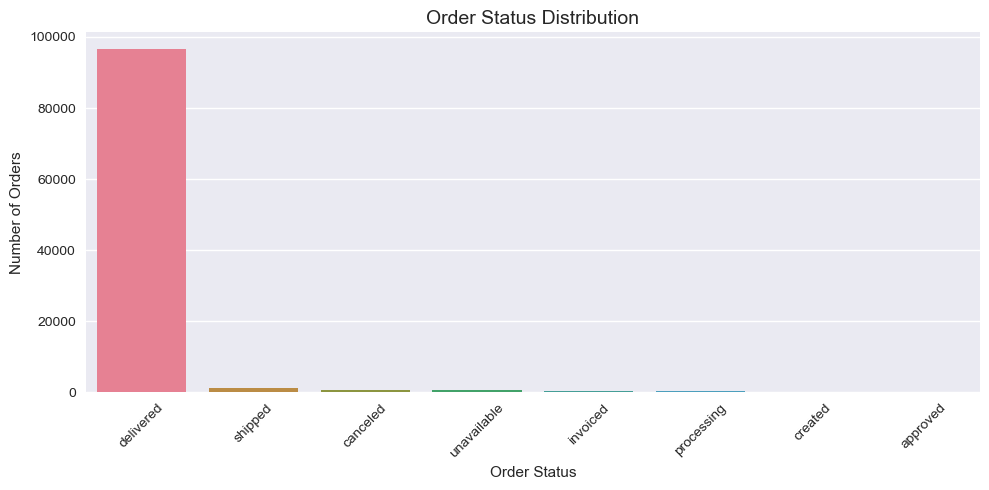

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(10, 5))

order_counts = orders['order_status'].value_counts()

sns.barplot(x=order_counts.index, y=order_counts.values, palette='husl')

plt.title('Order Status Distribution', fontsize=14)
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/01_order_status.png')
plt.show()

print(order_counts)

## Finding 1 - Order Status
97% of all orders are successfully delivered, indicating a very healthy and reliable e-commerce platform. 
The cancellation rate is less than 1%, which is excellent.

## Visualization 2 - Monthly Revenue Trend

C:\Users\ilayda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ilayda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


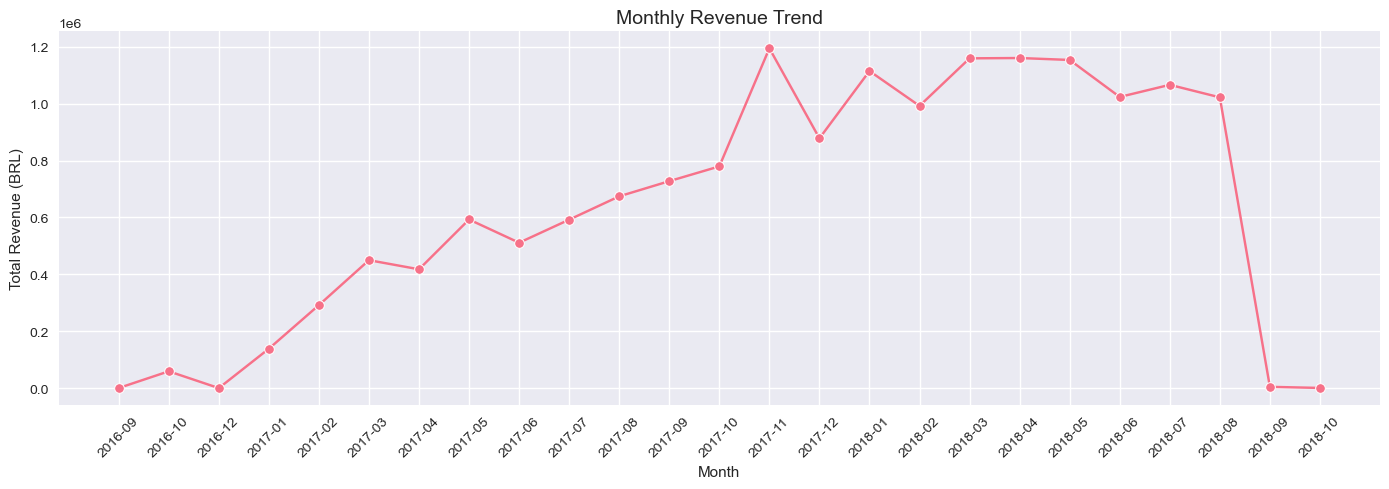

In [18]:
# First merge orders with payments
orders_payments = orders.merge(payments, on='order_id', how='inner')

# Convert purchase timestamp to datetime
orders_payments['order_purchase_timestamp'] = pd.to_datetime(orders_payments['order_purchase_timestamp'])

# Extract year-month
orders_payments['year_month'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')

# Group by month and sum revenue
monthly_revenue = orders_payments.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='year_month', y='payment_value', marker='o')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/02_monthly_revenue.png')
plt.show()

## Finding 2 - Monthly Revenue Trend
Revenue grew consistently from 2016 to 2018, peaking in November 2017 
(likely Black Friday). The platform shows strong growth trajectory 
with revenue stabilizing around 1M BRL per month in 2018.
The sharp drop at the end is due to incomplete data in the dataset.

## Visualization 3 - Review Score Distribution

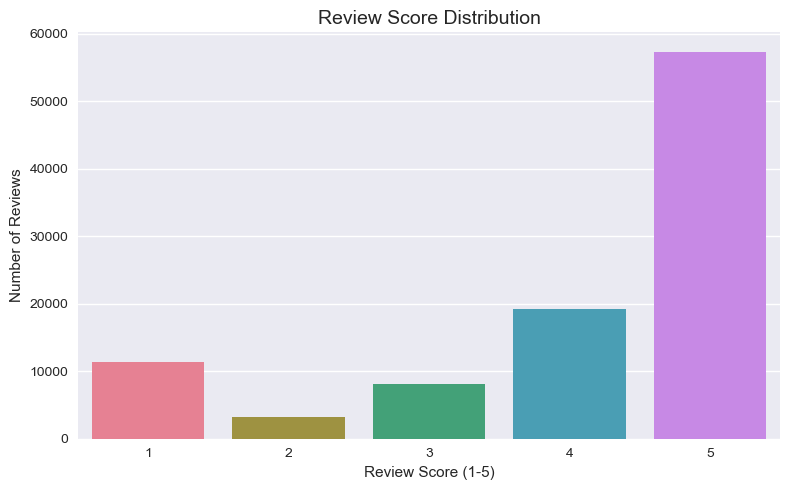

Score 1: 11424 reviews (11.5%)
Score 2: 3151 reviews (3.2%)
Score 3: 8179 reviews (8.2%)
Score 4: 19142 reviews (19.3%)
Score 5: 57328 reviews (57.8%)


In [19]:
plt.figure(figsize=(8, 5))

review_counts = reviews['review_score'].value_counts().sort_index()

sns.barplot(x=review_counts.index, y=review_counts.values, palette='husl')
plt.title('Review Score Distribution', fontsize=14)
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('outputs/03_review_scores.png')
plt.show()

# Print percentages
total = review_counts.sum()
for score, count in review_counts.items():
    print(f"Score {score}: {count} reviews ({count/total*100:.1f}%)")

## Finding 3 - Review Score Distribution
77% of customers rated their experience 4 or 5 stars, showing very high 
satisfaction levels. Only 11.5% gave 1 star. The platform maintains 
strong customer satisfaction with an average score of 4.09/5.

## Visualization 4 - Top 10 Product Categories by Sales

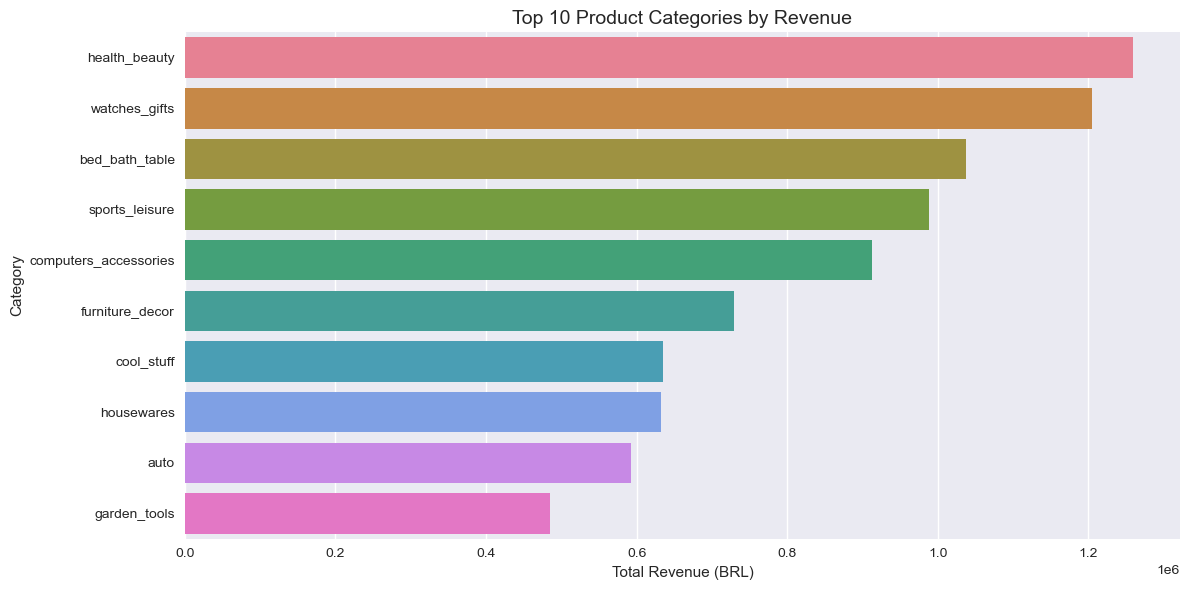

  product_category_name_english       price
0                 health_beauty  1258681.34
1                 watches_gifts  1205005.68
2                bed_bath_table  1036988.68
3                sports_leisure   988048.97
4         computers_accessories   911954.32
5               furniture_decor   729762.49
6                    cool_stuff   635290.85
7                    housewares   632248.66
8                          auto   592720.11
9                  garden_tools   485256.46


In [21]:
# Merge order_items with products to get category names
items_products = order_items.merge(products[['product_id', 'product_category_name_english']], 
                                    on='product_id', how='left')

# Group by category and sum revenue
category_revenue = items_products.groupby('product_category_name_english')['price'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10).reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x='price', y='product_category_name_english', palette='husl')
plt.title('Top 10 Product Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('outputs/04_top_categories.png')
plt.show()

print(category_revenue)

## Finding 4 - Top Product Categories
Health & Beauty is the top revenue-generating category (1.26M BRL), 
followed by Watches & Gifts and Bed, Bath & Table. 
Lifestyle and personal care products dominate the platform, 
suggesting Olist's core customer base prioritizes these categories.

## Visualization 5 - Price vs Freight Value Correlation

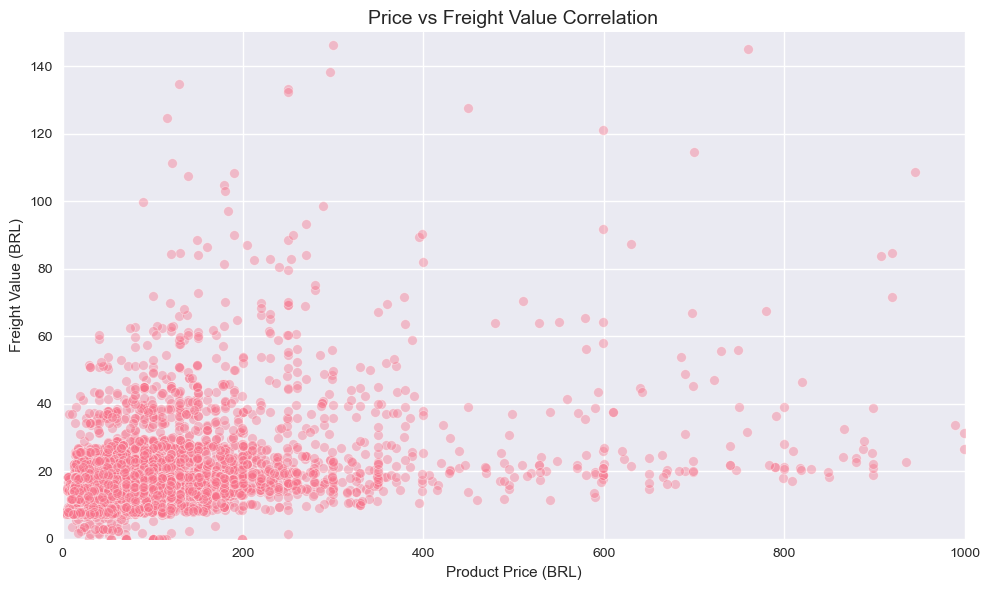

Correlation between price and freight: 0.414


In [22]:
# Sample 5000 rows to make chart readable
sample = order_items.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='price', y='freight_value', alpha=0.4)
plt.title('Price vs Freight Value Correlation', fontsize=14)
plt.xlabel('Product Price (BRL)')
plt.ylabel('Freight Value (BRL)')
plt.xlim(0, 1000)  # limit x axis to remove extreme outliers
plt.ylim(0, 150)   # limit y axis to remove extreme outliers
plt.tight_layout()
plt.savefig('outputs/05_price_freight_correlation.png')
plt.show()

# Print correlation coefficient
correlation = order_items['price'].corr(order_items['freight_value'])
print(f"Correlation between price and freight: {correlation:.3f}")

## Finding 5 - Price vs Freight Correlation
There is a moderate positive correlation (0.414) between product price 
and freight value. While more expensive products tend to cost slightly 
more to ship, the relationship is not strong — shipping costs are 
likely driven more by product size and weight than price.

In [23]:
# Export clean merged CSV for analysis

# Merge main tables together
df_master = orders.merge(order_items, on='order_id', how='left')
df_master = df_master.merge(customers, on='customer_id', how='left')
df_master = df_master.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
df_master = df_master.merge(payments[['order_id', 'payment_type', 'payment_value']], on='order_id', how='left')
df_master = df_master.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Save to outputs folder
df_master.to_csv('outputs/olist_master.csv', index=False)

print(f"Master dataset shape: {df_master.shape}")
print(f"\nColumns: {list(df_master.columns)}")
print("\nSaved to outputs/olist_master.csv ✅")

Master dataset shape: (119143, 22)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name_english', 'payment_type', 'payment_value', 'review_score']

Saved to outputs/olist_master.csv ✅
